#### Student Name: Kevin Cao
#### Student ID: A18315089


# Assignment 1

### Probability (Mozart Dice Game), Fourier Transforms (Find Frequency)

Instructions: 

This notebook is an interactive assignment; please read and follow the instructions in each cell.

Assignments are to be completed individually.

Cells that require your input (in the form of code or written response) will have 'Question #' above.

After completing the assignment, please submit this notebook as a PDF and your Mozart Dice Game MIDI.

Make sure to mark the page with your solution for each problem on Gradescope. Any problems without the correct pages marked may receive a score of 0. 

Mozart Dice Game
--------------

For this section of the assignment, you will implement the Mozart Dice Game using MIDI. 

Your composition will be a 16-measure minuet using 'dice rolls' (random generation in Python). 

Please check out the interactive demo available here (http://www.playonlinedicegames.com/mozart). 

Please see the code in the cell below for an example of combining MIDI files together (since you will be combining musical cells to create your Mozart Dice Game composition). You may want to install MIT's music21 python library (http://web.mit.edu/music21/) using pip. If you would rather combine MIDI files with another method, feel free to explore. 

The MIDI files, created by Packard Humanities Institute's Center for Computer Assisted Research in the Humanities at Stanford University, can be found in a .zip archive in the assignment repository. 

The code cell below also contains the filenames of candidate phrases for each of the 16 measures of your Mozart Dice Menuet (A1-B8). Using a random 'dice roll,' you will select one of the candidates for that measure of your minuet. The final product is the stitched-together combination of all 16 measures, selected via dice roll. 

Please save a .midi file of your randomly generated minuet to submit to Gradescope.

In [7]:
from music21 import midi as midi21
from music21 import stream
import copy
import music21
import soundfile as sf
from __future__ import  division
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import scipy
from scipy import signal
import librosa
%matplotlib inline
import IPython.display as ipydisplay
from IPython.display import Audio, display

def play(x):
    """Returns nothing. Outputs a midi realization of x, a note or stream.
    Primarily for use in notebooks and web environments.
    """  
    if isinstance(x, stream.Stream):
        x = copy.deepcopy(x)
        for subStream in x.recurse(streamsOnly=True, includeSelf=True):
            mss = subStream.getElementsByClass(stream.Measure)
            for ms in mss:
                ms.offset += 1.0
    if isinstance(x, music21.note.Note):
        s = stream.Stream()
        s.append(music21.note.Rest(1))
        s.append(x)
        x = s
    x.show('midi')

mf1 = midi21.MidiFile()
mf1.open("mozartdicegame/cda001.mid")
mf1.read()
mf1.close()
s1 = midi21.translate.midiFileToStream(mf1)

mf2 = midi21.MidiFile()
mf2.open("mozartdicegame/cda002.mid")
mf2.read()
mf2.close()
s2 = midi21.translate.midiFileToStream(mf2)

myStream = stream.Stream()
myStream.append(s1)
myStream.append(s2)
myStream.makeMeasures(inPlace = True)
play(myStream)
myStream.write('midi', fp='combined_midi.mid')


A1 = "070 010 033 036 105 165 007 142 099 085 145"
A2 = "014 064 001 114 150 152 081 106 068 045 097"
A3 = "164 100 160 008 057 112 131 040 086 090 006"
A4 = "122 012 163 035 071 015 037 069 139 158 121"
A5 = "025 149 077 111 117 147 021 043 120 082 056"
A6 = "153 030 156 039 052 027 125 140 092 123 067"
A7 = "018 161 168 137 132 073 049 023 143 078 063" 
A8 = "167 011 172 044 130 102 115 089 083 058 016"

B1 = "155 148 022 004 136 144 116 066 093 061 050"
B2 = "003 028 176 157 091 104 133 124 055 034 079" 
B3 = "162 135 062 038 138 087 072 026 029 119 175" 
B4 = "170 173 126 009 019 107 141 084 051 046 076" 
B5 = "013 169 031 151 134 128 094 075 042 059 113" 
B6 = "166 174 024 032 101 048 080 103 110 054 088" 
B7 = "095 002 159 017 154 109 129 096 108 060 053" 
B8 = "005 020 041 171 146 074 065 127 098 047 118" 


##### Question 1 (Including Output MIDI) [30 points]

In [8]:
# Put all A/B strings in a list, in order A1–A8, B1–B8
measure_strings = [A1, A2, A3, A4, A5, A6, A7, A8,
                   B1, B2, B3, B4, B5, B6, B7, B8]

# For each measure, split into IDs and randomly choose one
chosen_ids = [
    np.random.choice(m_str.split())
    for m_str in measure_strings
]

print("Chosen phrase IDs:", chosen_ids)

def load_phrase_stream(phrase_id):
    filename = f"mozartdicegame/cda{phrase_id}.mid"
    mf = midi21.MidiFile()
    mf.open(filename)
    mf.read()
    mf.close()
    return midi21.translate.midiFileToStream(mf)

# Load all chosen phrases and stitch them
phrase_streams = [load_phrase_stream(pid) for pid in chosen_ids]

minuet_stream = stream.Stream()
for ps in phrase_streams:
    minuet_stream.append(ps)
minuet_stream.makeMeasures(inPlace=True)

# Play and save
play(minuet_stream)
output_filename = "mozart_dice_minuet.mid"
minuet_stream.write("midi", fp=output_filename)

print("Saved dice game minuet to", output_filename)

Chosen phrase IDs: [np.str_('105'), np.str_('014'), np.str_('008'), np.str_('122'), np.str_('056'), np.str_('125'), np.str_('078'), np.str_('167'), np.str_('116'), np.str_('079'), np.str_('062'), np.str_('170'), np.str_('013'), np.str_('024'), np.str_('129'), np.str_('098')]


Saved dice game minuet to mozart_dice_minuet.mid


Fourier Transform
--------------

The Discrete Fourier Transform (DFT) is the primary analysis tool for digital signal processing. By using matrix/vector representation, the DFT can be understood as a transformation of digital signals into a new vector space.

In this space  the columns of the DFT are the basis vectors. One important idea is that we call these vectors as "frequencies", but mathematically they simply represent the original data in a different space.

This is the mathematical definition of DFT matrix

$$ \mathbf{U} = \frac{1}{\sqrt N} \left[ \exp \left( j \frac{2\pi}{N} n k \right) \right]_{n\in\{0,N_s-1\},k\in\{0,N-1\}} $$


where $n$ counts the samples as rows and $k$ indexes the discrete frequencies (which are our new basis) as columns. 

##### Question 2 [30 points]

In [9]:
def dftmatrix(Nfft=32,N=None):
    'construct DFT matrix'
    k= np.arange(Nfft)
    if N is None: N = Nfft
    n = np.arange(N)
    
    ### Implement the DFT matrix (U) here
    nk = np.outer(n, k)  # shape (N, Nfft)
    U = np.exp(1j * 2 * np.pi * nk / N)
    
    
    return U/np.sqrt(Nfft)

Nfft=8
Ns=8
U = dftmatrix(Nfft=Nfft,N=Ns)

We can plot these basis as pairs of real and imaginary vectors

Text(0.5, 0, 'n')

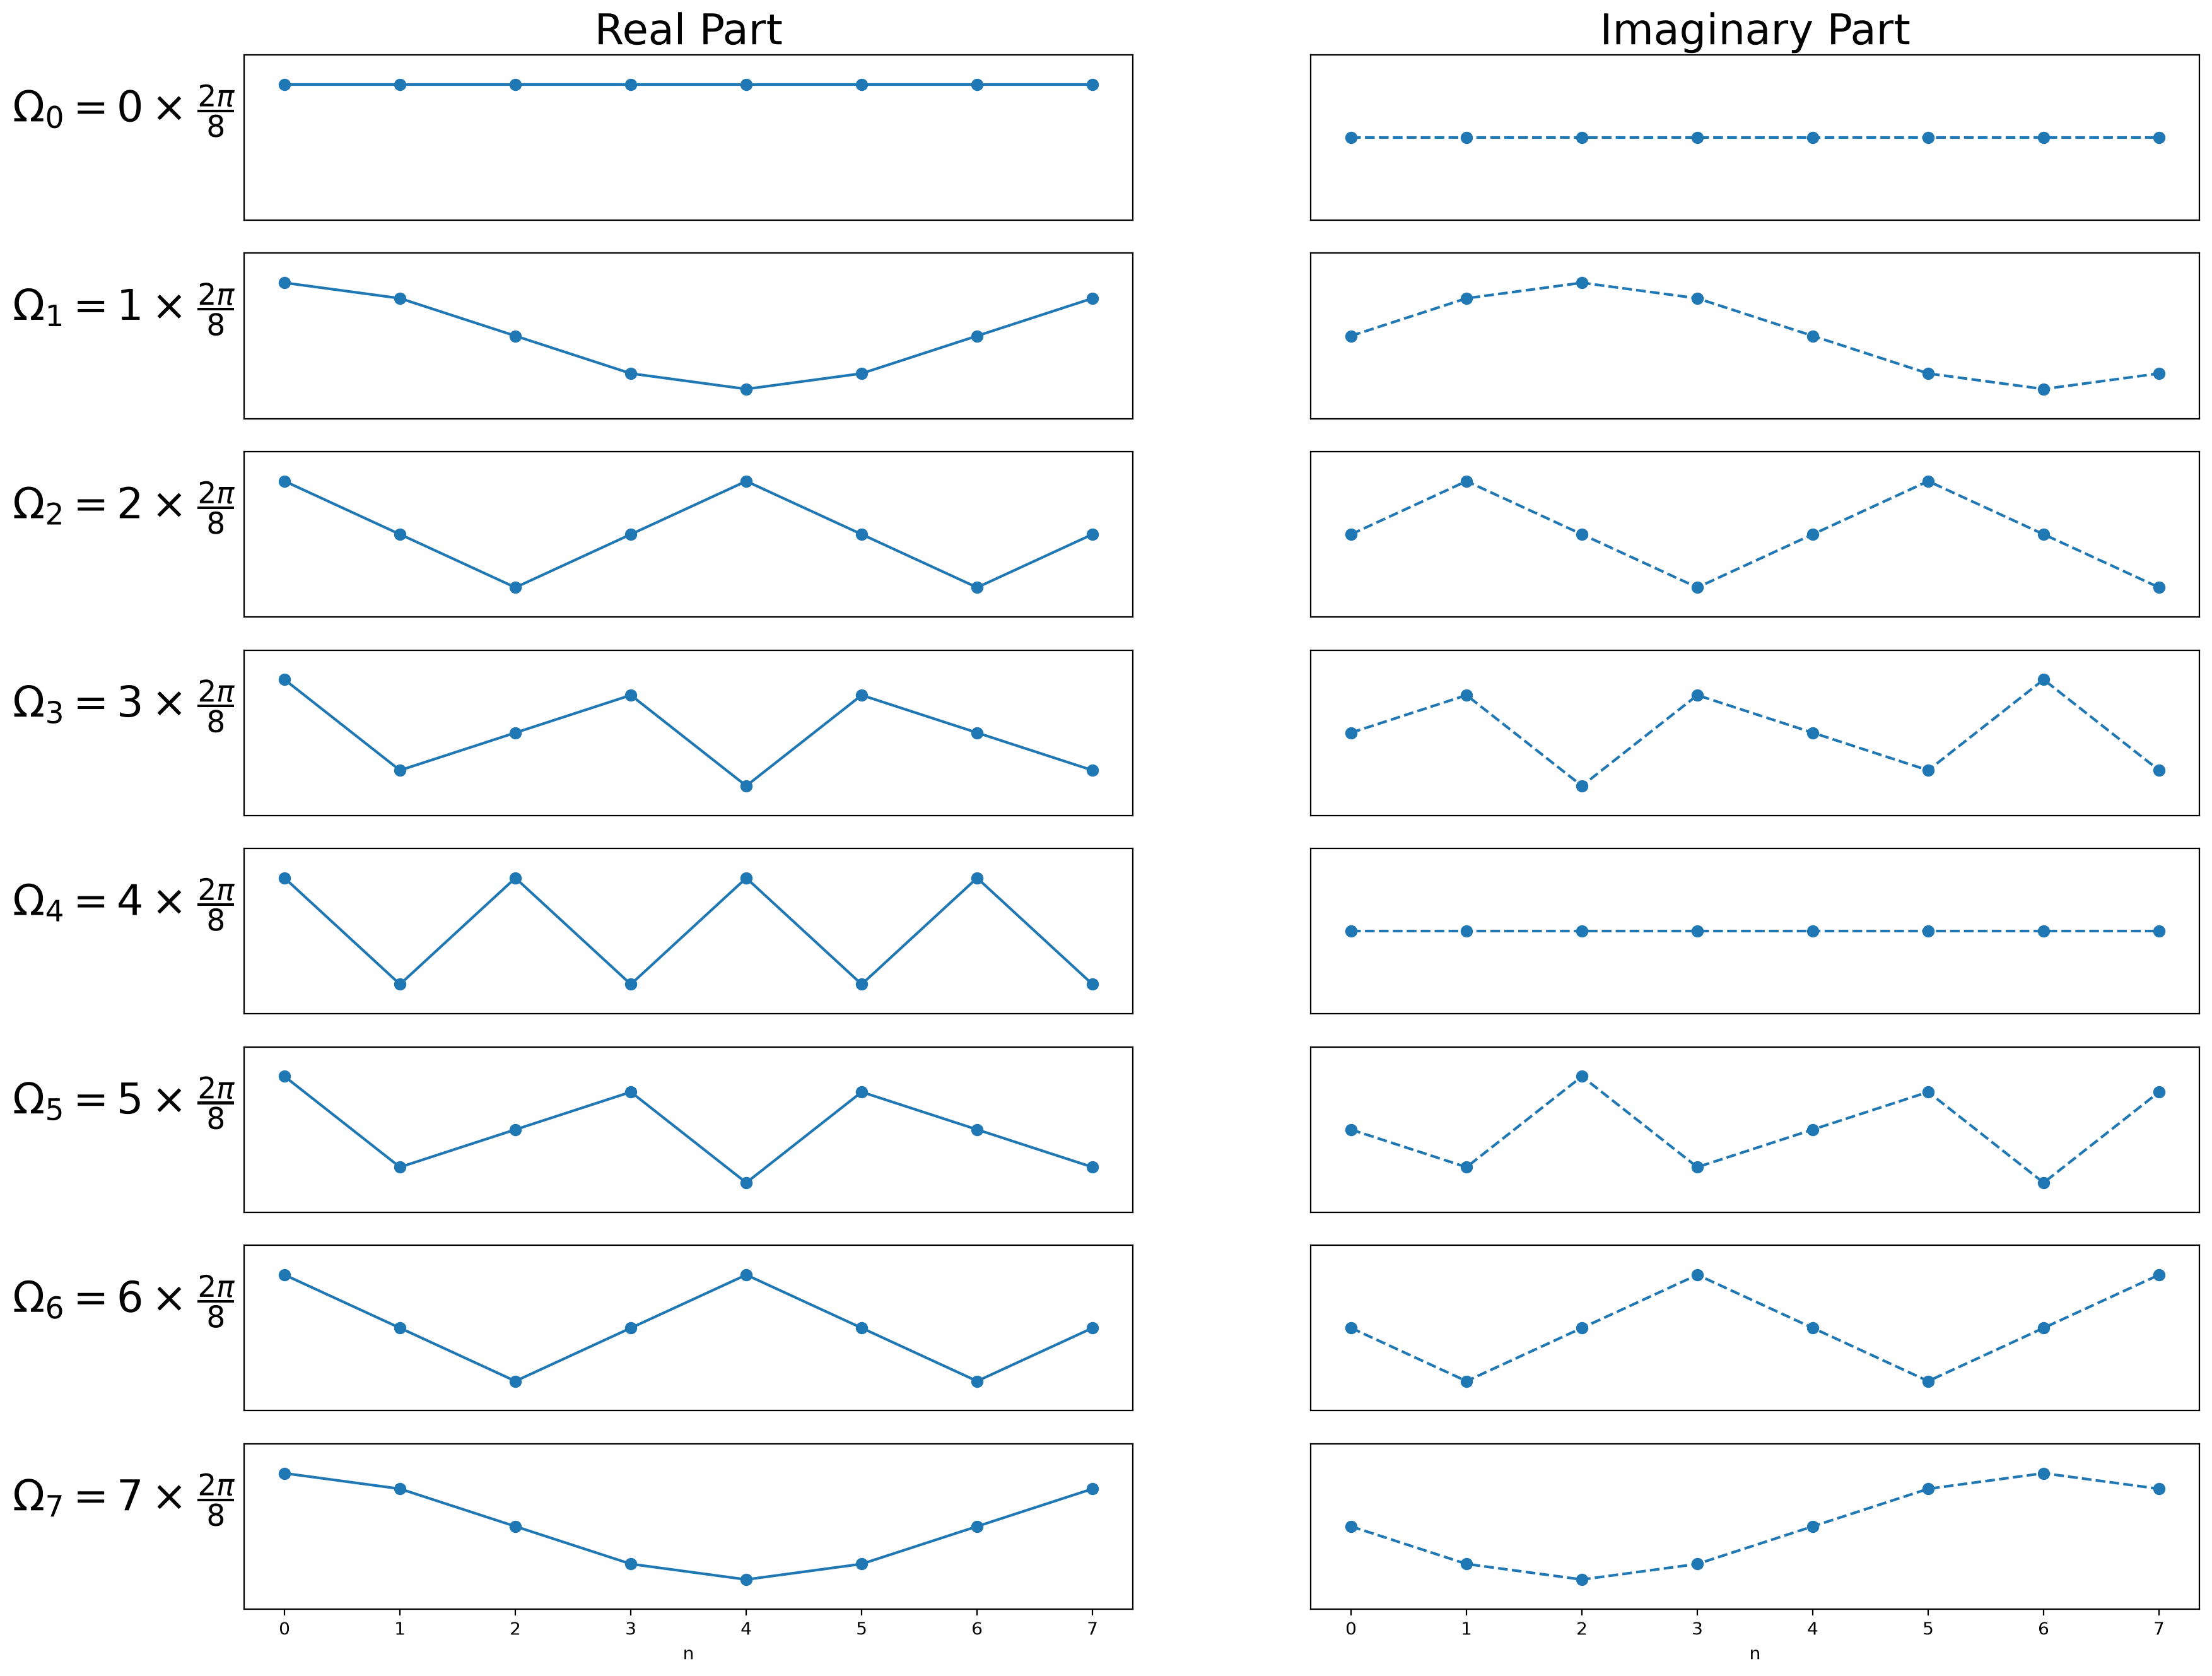

In [10]:
plt.rcParams['figure.figsize'] = (20, 16)

# plots in the left column
plt.subplot(Nfft,2,1)
plt.title('Real Part',fontsize=24)

for i in range(Nfft):
    plt.subplot(Nfft,2,2*i+1)
    plt.xticks([]);  plt.yticks([])
    plt.ylabel(r'$\Omega_{%d}=%d\times\frac{2\pi}{8}$'%(i,i),fontsize=24, 
        rotation='horizontal',horizontalalignment='right')
    plt.plot(np.array(U.real[:,i]),'-o')
    plt.axis(ymax=4/Nfft*1.1,ymin=-4/Nfft*1.1)
plt.xticks(np.arange(Nfft))
plt.xlabel('n')

# plots in the  right column
plt.subplot(Nfft,2,2)
plt.title('Imaginary Part',fontsize=24)

for i in range(Nfft):
    ax=plt.subplot(Nfft,2,2*(i+1))
    plt.xticks([]);  plt.yticks([])
    plt.plot(np.array(U.imag[:,i]),'--o')
    plt.axis(ymax=4/Nfft*1.1,ymin=-4/Nfft*1.1)    
plt.xticks(np.arange(Nfft))
plt.xlabel('n')

##### Question 3 [10 points]

What do you observe in the above plots, considering symmetries and the relationship between real & imaginary parts?

In these plots, each column of \(U\) is a complex sinusoid: the real part looks like a sampled cosine and the imaginary part like a sampled sine, with higher \(k\) giving faster oscillations. 

The basis at \(\Omega_k\) and \(\Omega_{8-k}\) form conjugate pairs, so their real parts appear mirrored and their imaginary parts have opposite sign, showing the typical symmetry between positive and negative frequencies in the DFT. 

Computing the DFT
--------------------

To compute the DFT using the matrix, we calculate the following,

$$ \mathbf{X} = \mathbf{U}^H \mathbf{x}$$

which individually takes each of the columns of $\mathbf{U}$ and computes the inner product as the $i^{th}$ entry,

$$ \mathbf{X}_i = \mathbf{U}_i^H \mathbf{x}$$

That is, we are measuring the *degree of similarity* between each column of $\mathbf{U}$ and the input vector. We can think of this as the coefficient of the projection of $\mathbf{x}$ onto  $\mathbf{u}_i$.

We can retrieve the original input from the DFT by calculating

$$ \mathbf{x} = \mathbf{U} \mathbf{X} $$

### Example: finding a frequency of a signal

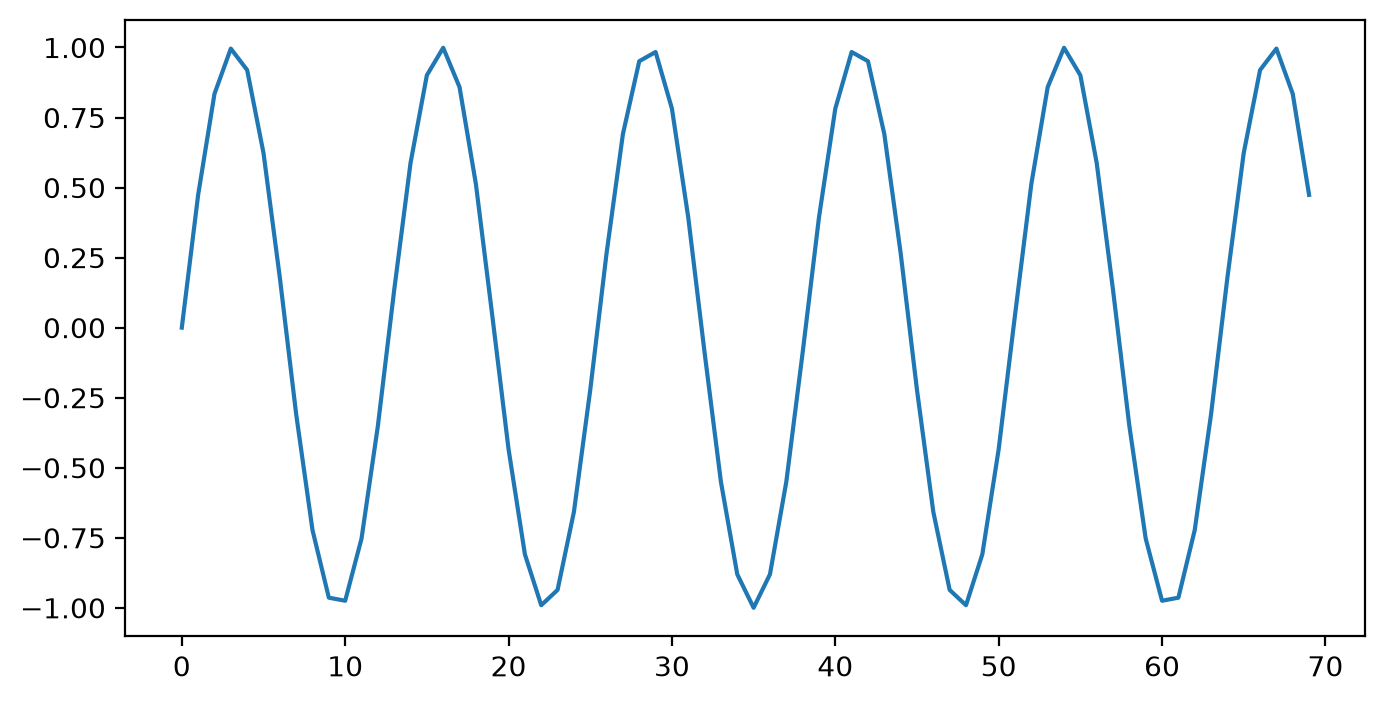

In [11]:
plt.rcParams['figure.figsize'] = (8, 4)

Ns = 70
freq = 5.5/Ns
t = np.arange(Ns)
x = np.sin(2*np.pi*freq*t)
plt.plot(x)
plt.show()

##### Question 4 [20 points]

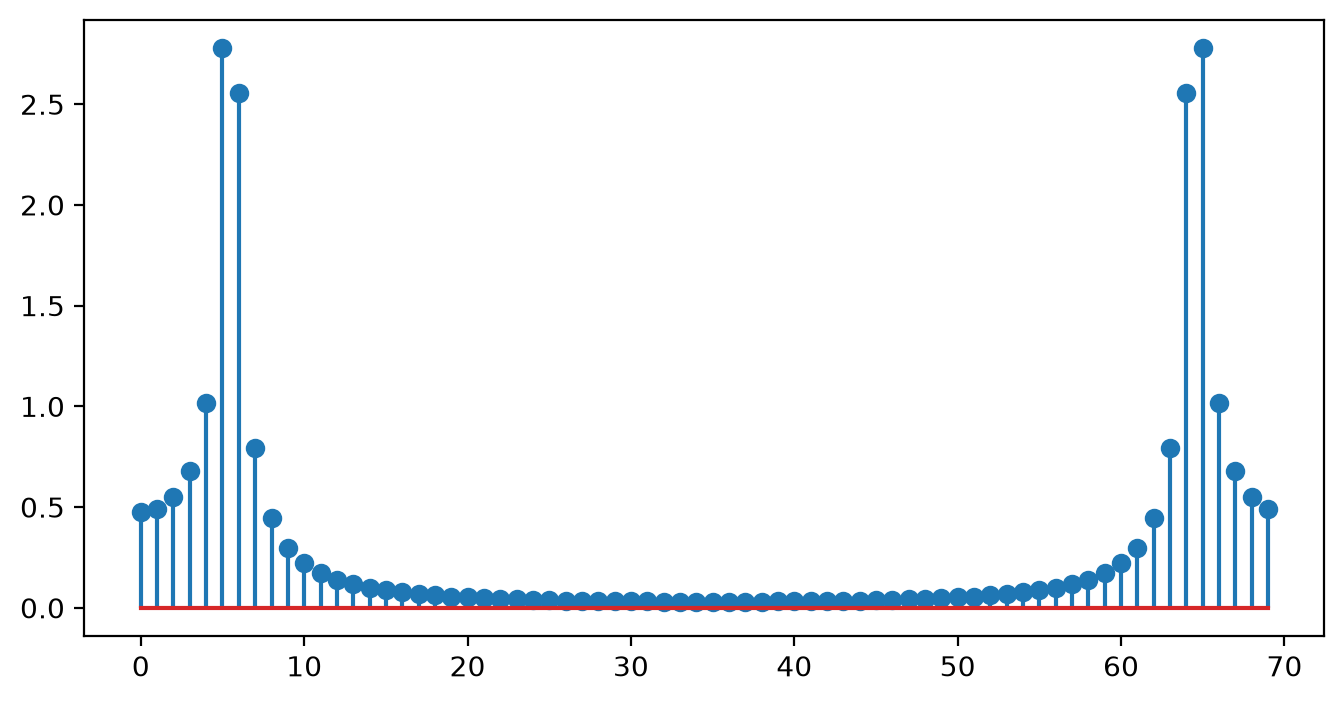

In [13]:
Nfft = Ns
U = dftmatrix(Nfft=Nfft,N=Ns)
x = np.matrix(x)

### Compute X, the DFT of signal x
X = U.conj().T @ x.T


plt.stem(np.array(abs(X)))
plt.show()

##### Question 5 [10 points]

Where do you observe peaks in the DFT plot? How would you describe the DFT plot symmetry? 

In the DFT magnitude plot, I see strong peaks at two symmetric frequency bins: one near the positive frequency corresponding to about 5.5 cycles over the window, and another near the mirrored bin at \(Nfft - 5.5\). For this real sinusoid, the spectrum is conjugate‑symmetric, so the magnitude \(|X[k]|\) is mirrored around the center of the plot: the left cluster of peaks is duplicated on the right, showing the usual positive/negative frequency symmetry of the DFT for real‑valued signals.